In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import sys
import importlib.util
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import neurite as ne

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

2026-03-05 21:23:40.682084: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-05 21:23:40.682132: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-05 21:23:40.683464: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Using device: cuda


In [ ]:
_pyc_dir = os.path.abspath(os.path.join('..', '__pycache__'))def _load_pyc(name):    pyc = os.path.join(_pyc_dir, f'{name}.cpython-310.pyc')    spec = importlib.util.spec_from_file_location(name, pyc)    mod = importlib.util.module_from_spec(spec)    spec.loader.exec_module(mod)    sys.modules[name] = mod_load_pyc('tuco_dataset')_load_pyc('multimodal_loss')from tuco_dataset import TucoDatasetfrom multimodal_loss import MINDLossfrom torch.utils.data import DataLoader, Subsettorch.backends.cudnn.benchmark = TrueDATA_ROOT = '../../Data/Tuco'MAX_SUBJECTS_TRAIN = 100MAX_SUBJECTS_VAL = Nonetrain_ds_full = TucoDataset(DATA_ROOT, split='train')val_ds_full = TucoDataset(DATA_ROOT, split='val')train_ds = Subset(train_ds_full, range(min(MAX_SUBJECTS_TRAIN, len(train_ds_full)))) \           if MAX_SUBJECTS_TRAIN else train_ds_fullval_ds = Subset(val_ds_full,   range(min(MAX_SUBJECTS_VAL,   len(val_ds_full))))   \           if MAX_SUBJECTS_VAL   else val_ds_fulltrain_loader = DataLoader(train_ds, batch_size=1, shuffle=True,  num_workers=2, pin_memory=True)val_loader = DataLoader(val_ds,   batch_size=1, shuffle=False, num_workers=2, pin_memory=True)DOWNSAMPLE = Trueraw = train_ds[0]['moving'].shape[1:]vol_shape = (96, 112, 96) if DOWNSAMPLE else tuple(raw)print('vol_shape:', vol_shape)print(f'Train subjects: {len(train_ds)}, Val subjects: {len(val_ds)}')

In [ ]:
def preprocess_batch(batch, device=device):    moving = batch['moving'].to(device, non_blocking=True)    fixed = batch['fixed'].to(device,  non_blocking=True)    moving_seg = batch['moving_seg'].to(device, non_blocking=True)    fixed_seg = batch['fixed_seg'].to(device, non_blocking=True)    if DOWNSAMPLE:        moving = F.interpolate(moving, scale_factor=0.5, mode='trilinear', align_corners=False)        moving = F.pad(moving, (0,0, 4,4, 4,4))        fixed = F.interpolate(fixed, scale_factor=0.5, mode='trilinear', align_corners=False)        fixed = F.pad(fixed, (0,0, 4,4, 4,4))        moving_seg = moving_seg.float()        moving_seg = F.interpolate(moving_seg, scale_factor=0.5, mode='nearest')        moving_seg = F.pad(moving_seg, (0,0, 4,4, 4,4))        fixed_seg = fixed_seg.float()        fixed_seg = F.interpolate(fixed_seg, scale_factor=0.5, mode='nearest')        fixed_seg = F.pad(fixed_seg, (0,0, 4,4, 4,4))    return moving, fixed, moving_seg, fixed_seg# Per MambaMorph: ignore labels 0 (background), 5 and 24 (noisy regions)SEG_LABELS = [2, 3, 4, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 26, 28]N_LABELS = len(SEG_LABELS)print(f'{N_LABELS} anatomical labels (ignoring 0, 5, 24): {SEG_LABELS}')def seg_to_onehot(seg, labels=SEG_LABELS):    seg_squeezed = seg[:, 0].long()    onehot = torch.zeros(seg.shape[0], len(labels), *seg.shape[2:],                         device=seg.device, dtype=seg.dtype)    for i, lbl in enumerate(labels):        onehot[:, i] = (seg_squeezed == lbl).float()    return onehotdef dice_loss(pred_onehot, gt_onehot, eps=1e-5):    dims = tuple(range(2, pred_onehot.ndim))    intersection = (pred_onehot * gt_onehot).sum(dim=dims)    union = pred_onehot.sum(dim=dims) + gt_onehot.sum(dim=dims)    dice_per_label = (2.0 * intersection + eps) / (union + eps)    return 1.0 - dice_per_label.mean()def dice_loss_efficient(flow, moving_seg, fixed_seg, transformer,                        labels=SEG_LABELS, eps=1e-5):    # Warps one label at a time to avoid full one-hot allocation
    seg_m = moving_seg[:, 0].long()    seg_f = fixed_seg[:, 0].long()    dims = (1, 2, 3)    dice_sum = 0.0    for lbl in labels:        m_bin = (seg_m == lbl).float().unsqueeze(1)        f_bin = (seg_f == lbl).float()        w_bin = transformer(m_bin, flow)[:, 0]        intersection = (w_bin * f_bin).sum(dim=dims)        union = w_bin.sum(dim=dims) + f_bin.sum(dim=dims)        dice_sum = dice_sum + (2.0 * intersection + eps) / (union + eps)    return 1.0 - (dice_sum / len(labels)).mean()

In [4]:
class SpatialTransformer3D(nn.Module):
    def forward(self, src, flow):
        b, _, d, h, w = src.shape
        device = src.device

        zz, yy, xx = torch.meshgrid(
            torch.arange(d, device=device),
            torch.arange(h, device=device),
            torch.arange(w, device=device),
            indexing='ij'
        )
        base_grid = torch.stack((xx, yy, zz), dim=0).float()
        base_grid = base_grid.unsqueeze(0).repeat(b, 1, 1, 1, 1).to(flow)

        pts = base_grid + flow
        x = 2.0 * (pts[:, 0] / (w - 1.0)) - 1.0
        y = 2.0 * (pts[:, 1] / (h - 1.0)) - 1.0
        z = 2.0 * (pts[:, 2] / (d - 1.0)) - 1.0

        grid = torch.stack((x, y, z), dim=-1)
        return F.grid_sample(src, grid, mode='bilinear', padding_mode='border', align_corners=True)

In [5]:
def flow_grad_l2(flow):
    dx = flow[:, :, :, :, 1:] - flow[:, :, :, :, :-1]
    dy = flow[:, :, :, 1:, :] - flow[:, :, :, :-1, :]
    dz = flow[:, :, 1:, :, :] - flow[:, :, :-1, :, :]
    dx = F.pad(dx, (0, 1, 0, 0, 0, 0))
    dy = F.pad(dy, (0, 0, 0, 1, 0, 0))
    dz = F.pad(dz, (0, 0, 0, 0, 0, 1))
    return dx.pow(2).mean() + dy.pow(2).mean() + dz.pow(2).mean()

In [6]:
from torch.utils.checkpoint import checkpoint as ckpt


class ConvBlock3D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv3d(in_channels, out_channels, kernel_size=3, padding=1)
        self.act = nn.LeakyReLU(0.2)

    def forward(self, x):
        return self.act(self.conv(x))


class VxmDense3D(nn.Module):
    def __init__(self, vol_shape, enc_feats=(16, 32, 32, 32), final_feats=(32, 16)):
        super().__init__()
        self.vol_shape = vol_shape

        self.encoders = nn.ModuleList()
        in_ch = 2
        for nf in enc_feats:
            self.encoders.append(ConvBlock3D(in_ch, nf))
            in_ch = nf
        self.pool = nn.MaxPool3d(2)
        self.bottleneck = ConvBlock3D(enc_feats[-1], enc_feats[-1])

        self.decoders = nn.ModuleList()
        dec_in = enc_feats[-1]
        for skip_ch in reversed(enc_feats):
            self.decoders.append(ConvBlock3D(dec_in + skip_ch, skip_ch))
            dec_in = skip_ch

        self.final_conv0 = ConvBlock3D(dec_in, final_feats[0])
        self.final_conv1 = ConvBlock3D(final_feats[0], final_feats[1])
        self.flow = nn.Conv3d(final_feats[1], 3, kernel_size=3, padding=1)
        self.transformer = SpatialTransformer3D()

        self.apply(self._init_weights)
        nn.init.zeros_(self.flow.weight)
        nn.init.zeros_(self.flow.bias)

    @staticmethod
    def _init_weights(m):
        if isinstance(m, nn.Conv3d):
            nn.init.kaiming_normal_(m.weight, nonlinearity='leaky_relu')
            if m.bias is not None:
                nn.init.zeros_(m.bias)

    def forward(self, src, tgt, compute_moved=True):
        x = torch.cat([src, tgt], dim=1)
        skips = []
        for enc in self.encoders:
            x = ckpt(enc, x, use_reentrant=False)
            skips.append(x)
            x = self.pool(x)

        x = ckpt(self.bottleneck, x, use_reentrant=False)

        for skip, dec in zip(reversed(skips), self.decoders):
            x = F.interpolate(x, scale_factor=2, mode='trilinear', align_corners=True)
            x = torch.cat([x, skip], dim=1)
            x = ckpt(dec, x, use_reentrant=False)

        x = ckpt(self.final_conv0, x, use_reentrant=False)
        x = ckpt(self.final_conv1, x, use_reentrant=False)
        flow = self.flow(x)
        moved = self.transformer(src, flow) if compute_moved else None
        return moved, flow

In [ ]:
model = VxmDense3D(vol_shape=vol_shape, enc_feats=(16, 32, 32, 32), final_feats=(32, 16)).to(device)
model.eval()
with torch.no_grad():
    _b = next(iter(train_loader))
    _m, _f, _ms, _fs = preprocess_batch(_b)
    _moved, _flow = model(_m, _f)
    print('moved:', tuple(_moved.shape), '  flow:', tuple(_flow.shape))

    _dl = dice_loss_efficient(_flow, _ms, _fs, model.transformer)
    print(f'dice_loss_efficient: {_dl.item():.4f}')

del _b, _m, _f, _ms, _fs, _moved, _flow, _dl
torch.cuda.empty_cache()

vram_used = torch.cuda.memory_allocated() / 1e6
vram_total = torch.cuda.get_device_properties(0).total_mem / 1e9
print(f'VRAM after init: {vram_used:.0f} MB  |  GPU total: {vram_total:.1f} GB')

In [ ]:
epochs = 1500smooth_weight = 0.1steps_per_epoch = len(train_loader)ckpt_every = 50save_dir = '../trained_weights'ckpt_dir = os.path.join(save_dir, '3d_checkpoints')os.makedirs(save_dir, exist_ok=True)os.makedirs(ckpt_dir, exist_ok=True)best_model_path = os.path.join(save_dir, '3d_dense_best.pth')model = VxmDense3D(vol_shape=vol_shape, enc_feats=(16, 32, 32, 32), final_feats=(32, 16)).to(device)optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)train_history = []val_history = []best_loss = float('inf')train_loader_moving = DataLoader(train_ds, batch_size=1, shuffle=True,  num_workers=2, pin_memory=True)train_loader_fixed = DataLoader(train_ds, batch_size=1, shuffle=True,  num_workers=2, pin_memory=True)print('Pre-computing fixed validation pairs...')val_pairs = []val_iter_m = iter(DataLoader(val_ds, batch_size=1, shuffle=True, num_workers=0))val_iter_f = iter(DataLoader(val_ds, batch_size=1, shuffle=True, num_workers=0))for _ in range(len(val_ds)):    bm = next(val_iter_m)    try:        bf = next(val_iter_f)    except StopIteration:        val_iter_f = iter(DataLoader(val_ds, batch_size=1, shuffle=True, num_workers=0))        bf = next(val_iter_f)    val_pairs.append((        bm['moving'].cpu(), bf['fixed'].cpu(),        bm['moving_seg'].cpu(), bf['fixed_seg'].cpu(),    ))print(f'{len(val_pairs)} fixed val pairs cached')print(f'\nTraining: {steps_per_epoch} steps/epoch, {epochs} epochs')print(f'Loss: Dice + {smooth_weight} x smooth | vol_shape {vol_shape}')for epoch in range(epochs):    model.train()    running_train = 0.0    nan_steps = 0    iter_moving = iter(train_loader_moving)    iter_fixed = iter(train_loader_fixed)    for step in range(steps_per_epoch):        try:            batch_m = next(iter_moving)        except StopIteration:            iter_moving = iter(train_loader_moving)            batch_m = next(iter_moving)        try:            batch_f = next(iter_fixed)        except StopIteration:            iter_fixed = iter(train_loader_fixed)            batch_f = next(iter_fixed)        cross_batch = {            'moving': batch_m['moving'],            'fixed': batch_f['fixed'],            'moving_seg': batch_m['moving_seg'],            'fixed_seg': batch_f['fixed_seg'],        }        moving, fixed, moving_seg, fixed_seg = preprocess_batch(cross_batch)        optimizer.zero_grad(set_to_none=True)        _, flow = model(moving, fixed, compute_moved=False)        smooth_loss = flow_grad_l2(flow)        d_loss = dice_loss_efficient(flow, moving_seg, fixed_seg, model.transformer)        loss = d_loss + smooth_weight * smooth_loss        if not torch.isfinite(loss):            nan_steps += 1            continue        loss.backward()        optimizer.step()        running_train += loss.item()        del moving, fixed, moving_seg, fixed_seg, flow        del smooth_loss, d_loss, loss        del batch_m, batch_f, cross_batch    valid_steps = steps_per_epoch - nan_steps    epoch_train = running_train / max(valid_steps, 1)    train_history.append(epoch_train)    if epoch % 10 == 0:        torch.cuda.empty_cache()    model.eval()    running_val = 0.0    with torch.no_grad():        for m_cpu, f_cpu, ms_cpu, fs_cpu in val_pairs:            moving = m_cpu.to(device)            fixed = f_cpu.to(device)            mov_seg = ms_cpu.to(device)            fix_seg = fs_cpu.to(device)            _, flow_v = model(moving, fixed, compute_moved=False)            smooth_v = flow_grad_l2(flow_v)            d_loss_v = dice_loss_efficient(flow_v, mov_seg, fix_seg, model.transformer)            loss_v = d_loss_v + smooth_weight * smooth_v            running_val += loss_v.item()            del moving, fixed, mov_seg, fix_seg, flow_v, smooth_v, d_loss_v, loss_v    epoch_val = running_val / len(val_pairs)    val_history.append(epoch_val)    nan_str = f'  ({nan_steps} NaN)' if nan_steps else ''    print(f'Epoch {epoch + 1}/{epochs} -- train: {epoch_train:.6f} | '          f'val: {epoch_val:.6f}{nan_str}')    if epoch_val < best_loss:        best_loss = epoch_val        torch.save(model.state_dict(), best_model_path)    if (epoch + 1) % ckpt_every == 0:        ckpt_path = os.path.join(ckpt_dir, f'3d_epoch_{epoch+1}.pth')        torch.save({            'epoch': epoch + 1,            'model_state_dict': model.state_dict(),            'optimizer_state_dict': optimizer.state_dict(),            'train_loss': epoch_train,            'val_loss': epoch_val,            'best_val_loss': best_loss,        }, ckpt_path)train_history = np.array(train_history, dtype=np.float32)val_history = np.array(val_history,   dtype=np.float32)print(f'Best val loss: {best_loss:.6f}')print(f'Peak VRAM during training: {torch.cuda.max_memory_allocated()/1e6:.0f} MB')

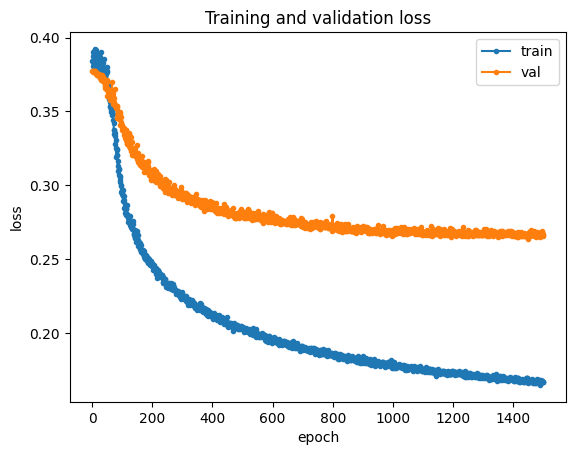

In [ ]:
epochs_ran = np.arange(1, len(train_history) + 1)
plt.figure()
plt.plot(epochs_ran, train_history, '.-', label='train')
plt.plot(epochs_ran, val_history,   '.-', label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

In [ ]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()


def mid_slices(vol):
    return [
        vol[vol.shape[0] // 2],
        vol[:, vol.shape[1] // 2, :],
        vol[:, :, vol.shape[2] // 2],
    ]


def visualise_registration(split_name, loader):
    batch = next(iter(loader))
    with torch.no_grad():
        moving, fixed, moving_seg, fixed_seg = preprocess_batch(batch)
        moved, flow = model(moving, fixed)

    trio = [
        ('moving', moving[0, 0].cpu().numpy()),
        ('fixed',  fixed[0, 0].cpu().numpy()),
        ('moved',  moved[0, 0].cpu().numpy()),
    ]
    views = ['axial', 'coronal', 'sagittal']

    plt.figure(figsize=(12, 8))
    for row, (title, vol) in enumerate(trio):
        for col, (view, slc) in enumerate(zip(views, mid_slices(vol))):
            plt.subplot(3, 3, row * 3 + col + 1)
            plt.imshow(slc, cmap='gray')
            plt.title(f'{split_name} {title} {view}')
            plt.axis('off')
    plt.tight_layout()
    plt.show()

    flow_np = flow[0].permute(1, 2, 3, 0).cpu().numpy()
    mid_z = flow_np.shape[0] // 2
    step = 4
    flow_ds = flow_np[mid_z, ::step, ::step, :2]
    ne.plot.flow([flow_ds], width=5)


visualise_registration('val',   val_loader)
visualise_registration('train', train_loader)

In [ ]:
from scipy.ndimage import distance_transform_edtimport timedef compute_dice_per_label(warped_seg, fixed_seg, labels=SEG_LABELS):    dice_scores = []    for lbl in labels:        w = (warped_seg == lbl).astype(np.float32)        f = (fixed_seg == lbl).astype(np.float32)        intersection = (w * f).sum()        union = w.sum() + f.sum()        if union == 0:            dice_scores.append(1.0)        else:            dice_scores.append(2.0 * intersection / union)    return np.array(dice_scores)def hausdorff_distance_95(seg1, seg2):    if seg1.sum() == 0 and seg2.sum() == 0:        return 0.0    if seg1.sum() == 0 or seg2.sum() == 0:        return np.inf    dt2 = distance_transform_edt(~seg2.astype(bool))    d12 = dt2[seg1.astype(bool)]    dt1 = distance_transform_edt(~seg1.astype(bool))    d21 = dt1[seg2.astype(bool)]    return max(np.percentile(d12, 95), np.percentile(d21, 95))def negative_jacobian_ratio(flow_np):    D, H, W, _ = flow_np.shape    grid = np.mgrid[:D, :H, :W].astype(np.float32).transpose(1, 2, 3, 0)    deform = flow_np + grid    J = np.zeros((D, H, W, 3, 3), dtype=np.float32)    for i in range(3):        J[..., i, 0] = np.gradient(deform[..., i], axis=0)        J[..., i, 1] = np.gradient(deform[..., i], axis=1)        J[..., i, 2] = np.gradient(deform[..., i], axis=2)    det = (J[...,0,0] * (J[...,1,1]*J[...,2,2] - J[...,1,2]*J[...,2,1]) -           J[...,0,1] * (J[...,1,0]*J[...,2,2] - J[...,1,2]*J[...,2,0]) +           J[...,0,2] * (J[...,1,0]*J[...,2,1] - J[...,1,1]*J[...,2,0]))    return np.sum(det <= 0) / det.sizeprint('Collecting validation subjects...')val_volumes_mr, val_volumes_ct = [], []val_segs_mr, val_segs_ct = [], []for batch in val_loader:    moving, fixed, moving_seg, fixed_seg = preprocess_batch(batch)    val_volumes_mr.append(moving.cpu())    val_volumes_ct.append(fixed.cpu())    val_segs_mr.append(moving_seg.cpu())    val_segs_ct.append(fixed_seg.cpu())n_val = len(val_volumes_mr)print(f'{n_val} validation subjects at {vol_shape}')np.random.seed(42)indices = np.random.permutation(n_val)n_pairs = n_val // 2pairings = [(indices[2*i], indices[2*i+1]) for i in range(n_pairs)]print(f'{n_pairs} cross-subject pairs')class NearestSpatialTransformer3D(nn.Module):    def forward(self, src, flow):        b, _, d, h, w = src.shape        device = src.device        zz, yy, xx = torch.meshgrid(            torch.arange(d, device=device),            torch.arange(h, device=device),            torch.arange(w, device=device), indexing='ij')        base_grid = torch.stack((xx, yy, zz), dim=0).float().unsqueeze(0).expand(b, -1, -1, -1, -1)        pts = base_grid + flow        x = 2.0 * (pts[:, 0] / (w - 1.0)) - 1.0        y = 2.0 * (pts[:, 1] / (h - 1.0)) - 1.0        z = 2.0 * (pts[:, 2] / (d - 1.0)) - 1.0        grid = torch.stack((x, y, z), dim=-1)        return F.grid_sample(src, grid, mode='nearest', padding_mode='border', align_corners=True)nearest_stn = NearestSpatialTransformer3D().to(device)dice_all = []hd95_all = []jacobian_all = []infer_times = []model.eval()with torch.no_grad():    for pair_idx, (i, j) in enumerate(pairings):        print(f'  Pair {pair_idx+1}/{n_pairs}: subj {i} -> subj {j}')        moving = val_volumes_mr[i].to(device)        fixed = val_volumes_ct[j].to(device)        moving_seg_int = val_segs_mr[i].to(device)        fixed_seg_int = val_segs_ct[j].to(device)        torch.cuda.synchronize()        t0 = time.time()        moved, flow = model(moving, fixed)        torch.cuda.synchronize()        t1 = time.time()        if pair_idx > 0:            infer_times.append(t1 - t0)        warped_labels = np.zeros(vol_shape, dtype=np.int16)        for li, lbl in enumerate(SEG_LABELS):            m_bin = (moving_seg_int[:, 0] == lbl).float().unsqueeze(1)            w_bin = nearest_stn(m_bin, flow)            w_np = w_bin[0, 0].cpu().numpy()            warped_labels[w_np > 0.5] = lbl        fixed_seg_np = fixed_seg_int[0, 0].cpu().numpy().astype(np.int16)        dice_scores = compute_dice_per_label(warped_labels, fixed_seg_np)        dice_all.append(dice_scores)        hd95_per_label = []        for li, lbl in enumerate(SEG_LABELS):            hd = hausdorff_distance_95(                (warped_labels == lbl).astype(np.uint8),                (fixed_seg_np == lbl).astype(np.uint8))            hd95_per_label.append(hd)        hd95_all.append(np.mean(hd95_per_label))        flow_np = flow[0].permute(1, 2, 3, 0).cpu().numpy()        jacobian_all.append(negative_jacobian_ratio(flow_np))        del moving, fixed, moving_seg_int, fixed_seg_int, moved, flow        torch.cuda.empty_cache()dice_all = np.stack(dice_all)dice_means = dice_all.mean(axis=1) * 100print(f'\nAvg Dice: {dice_means.mean():.2f} +/- {dice_means.std():.2f} %')print(f'|J| <= 0: {np.mean(jacobian_all):.6f} +/- {np.std(jacobian_all):.6f}')print(f'HD95: {np.mean(hd95_all):.2f} +/- {np.std(hd95_all):.2f}')if infer_times:    print(f'Inference time: {np.mean(infer_times):.4f} +/- {np.std(infer_times):.4f} s')print(f'Peak VRAM: {torch.cuda.max_memory_allocated()/1e9:.2f} GB')print(f'\nPer-label Dice (mean +/- std across {n_pairs} pairs):')for li, lbl in enumerate(SEG_LABELS):    print(f'  Label {lbl:3d}: {dice_all[:, li].mean()*100:6.2f} +/- {dice_all[:, li].std()*100:5.2f} %')del val_volumes_mr, val_volumes_ct, val_segs_mr, val_segs_cttorch.cuda.empty_cache()

In [ ]:
final_path = os.path.join(save_dir, '3d_dense.pth')
torch.save(model.state_dict(), final_path)
print('Saved final model to', final_path)
print('Best val loss model is at', best_model_path)

Saved final model to ../trained_weights/3d_dense.pth
Best val loss model is at ../trained_weights/3d_dense_best.pth
